In [1]:
! pip install git+https://github.com/amazon-science/chronos-forecasting.git

  Cloning https://github.com/amazon-science/chronos-forecasting.git to /private/var/folders/ck/9102qxqx7cb0nzwzg4my5wh00000gn/T/pip-req-build-6clstvst
  Running command git clone --filter=blob:none --quiet https://github.com/amazon-science/chronos-forecasting.git /private/var/folders/ck/9102qxqx7cb0nzwzg4my5wh00000gn/T/pip-req-build-6clstvst
  Resolved https://github.com/amazon-science/chronos-forecasting.git to commit 6d68ed7c4ed2805d122d77b4660765b4089de5ca
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


`torch_dtype` is deprecated! Use `dtype` instead!


RMSE:       180.60
MAPE:       1.42%
Pearson R²: 0.5915
Directional Accuracy: 30.00%


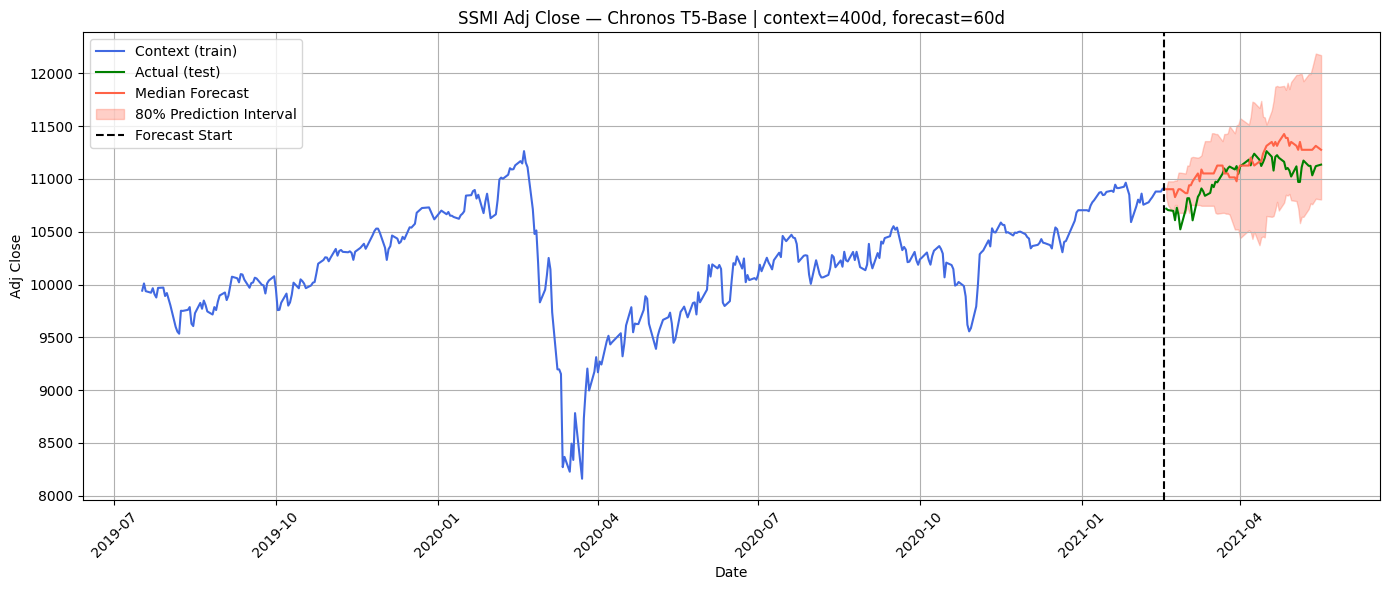

In [ ]:
import numpy as np
import pandas as pd
import torch
from chronos import ChronosPipeline
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy.stats import pearsonr

# the data
df = pd.read_csv("/Users/ismaelbrahimbelhaouari/Documents/St Gallen University /Deep Learning/DLSuperSlay/DataSets/SSMI cleaned/SSMI_cleaned.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Control window size
context_length    = 400
prediction_length = 60

total_window = context_length + prediction_length
df_window = df.tail(total_window).reset_index(drop=True)

y = df_window["Adj Close"].values.astype(float)

y_train = torch.tensor(y[:context_length], dtype=torch.float32)
y_test  = torch.tensor(y[context_length:], dtype=torch.float32)

# Load Chronos
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-base",
    device_map="mps",
    torch_dtype=torch.float32,
)

# Forecast
forecast = pipeline.predict(
    y_train,
    prediction_length=prediction_length,
    num_samples=20,
)

# Metrics
median_forecast = np.median(forecast[0].numpy(), axis=0)

rmse = np.sqrt(mean_squared_error(y_test.numpy(), median_forecast))
mape = mean_absolute_percentage_error(y_test.numpy(), median_forecast) * 100
pearson_r2 = pearsonr(y_test.numpy(), median_forecast).statistic ** 2
prev_values = np.concatenate([[y_train[-1].item()], y_test.numpy()[:-1]])
pred_prev = np.concatenate([[y_train[-1].item()], median_forecast[:-1]])
actual_direction = np.sign(y_test.numpy() - prev_values)
pred_direction = np.sign(median_forecast - pred_prev)
directional_accuracy = (actual_direction == pred_direction).mean() * 100

print(f"RMSE:       {rmse:.2f}")
print(f"MAPE:       {mape:.2f}%")
print(f"Pearson R²: {pearson_r2:.4f}")
print(f"Directional Accuracy: {directional_accuracy:.2f}%")

# Plot
dates      = df_window["Date"].values
test_dates = dates[context_length:context_length + prediction_length]

low, median, high = np.quantile(forecast[0].numpy(), [0.1, 0.5, 0.9], axis=0)

plt.figure(figsize=(14, 6))
plt.plot(dates[:context_length], y[:context_length], color="royalblue", label="Context (train)")
plt.plot(dates[context_length:], y[context_length:], color="green",     label="Actual (test)")
plt.plot(test_dates, median,                          color="tomato",    label="Median Forecast")
plt.fill_between(test_dates, low, high, color="tomato", alpha=0.3,       label="80% Prediction Interval")
plt.axvline(x=dates[context_length - 1], color="black", linestyle="--", label="Forecast Start")

plt.legend()
plt.grid()
plt.xlabel("Date")
plt.ylabel("Adj Close")
plt.title(f"SSMI Adj Close — Chronos T5-Base | context={context_length}d, forecast={prediction_length}d")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Experiments:
#### I will divide the data in segements each segment will be forecasted, each forecast will give a 
- #### RMSE,
- #### MAPE 
- #### R^2 value.
#### This will then be summarised using a box plot. 

`torch_dtype` is deprecated! Use `dtype` instead!


Segment 1/249 — RMSE: 54.31 | MAPE: 1.85% | R²: 0.3005 | Dir Acc: 26.7%
Segment 2/249 — RMSE: 24.71 | MAPE: 1.36% | R²: 0.3997 | Dir Acc: 73.3%
Segment 3/249 — RMSE: 22.66 | MAPE: 1.10% | R²: 0.4078 | Dir Acc: 33.3%
Segment 4/249 — RMSE: 19.62 | MAPE: 0.99% | R²: 0.6577 | Dir Acc: 40.0%
Segment 5/249 — RMSE: 32.33 | MAPE: 1.45% | R²: 0.0356 | Dir Acc: 26.7%
Segment 6/249 — RMSE: 14.53 | MAPE: 0.69% | R²: 0.1361 | Dir Acc: 26.7%
Segment 7/249 — RMSE: 54.32 | MAPE: 2.33% | R²: 0.4797 | Dir Acc: 26.7%
Segment 8/249 — RMSE: 58.25 | MAPE: 2.84% | R²: 0.1740 | Dir Acc: 40.0%
Segment 9/249 — RMSE: 28.39 | MAPE: 1.34% | R²: 0.1242 | Dir Acc: 33.3%
Segment 10/249 — RMSE: 72.35 | MAPE: 2.73% | R²: 0.3714 | Dir Acc: 13.3%
Segment 11/249 — RMSE: 50.18 | MAPE: 2.27% | R²: 0.6321 | Dir Acc: 26.7%
Segment 12/249 — RMSE: 59.39 | MAPE: 2.43% | R²: 0.6827 | Dir Acc: 20.0%
Segment 13/249 — RMSE: 32.14 | MAPE: 1.36% | R²: 0.0082 | Dir Acc: 40.0%
Segment 14/249 — RMSE: 48.00 | MAPE: 1.97% | R²: 0.6079 | Di

/var/folders/ck/9102qxqx7cb0nzwzg4my5wh00000gn/T/ipykernel_56356/2197387037.py:128: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)


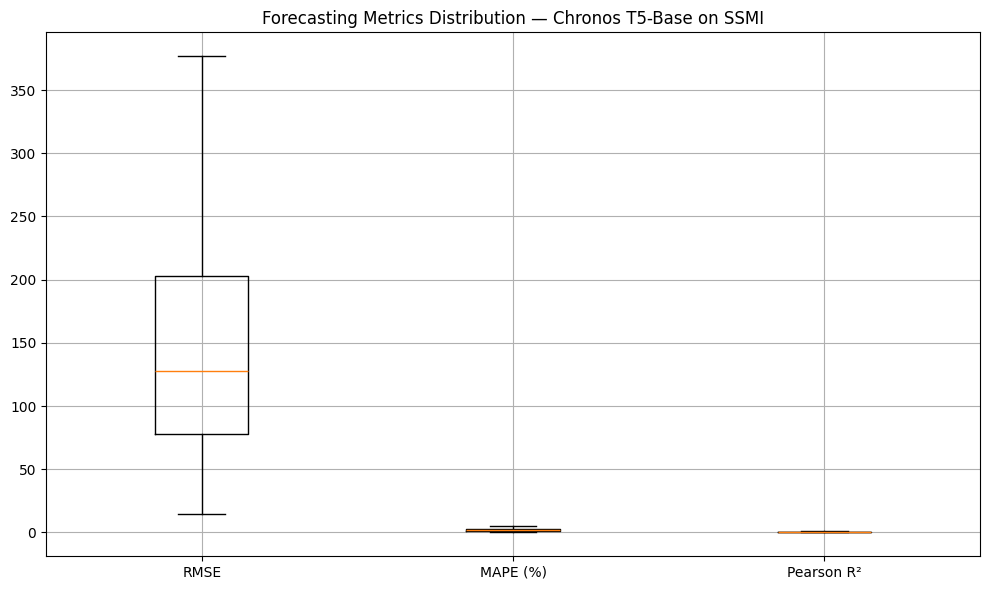

In [1]:
import numpy as np
import pandas as pd
import torch
from chronos import ChronosPipeline
import matplotlib.pyplot as plt
import logging
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy.stats import pearsonr

logging.basicConfig(
    filename='ChronosBase_SSMI_Metrics.log',
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s'
)

def main():
    try:
        # ========================
        # 1) Load SSMI data
        # ========================
        df = pd.read_csv("/Users/ismaelbrahimbelhaouari/Documents/St Gallen University /Deep Learning/DLSuperSlay/DataSets/SSMI cleaned/SSMI_cleaned.csv", parse_dates=["Date"])
        df = df.sort_values("Date").reset_index(drop=True)

        y = df["Adj Close"].values.astype(float)
        total_samples = len(y)
        logging.info(f"Total SSMI samples loaded: {total_samples}")

        # ========================
        # 2) Sliding window config
        # ========================
        context_window   = 180 # 200 
        forecast_horizon = 15
        step_size        = 30 # context_window + forecast_horizon
        num_segments     = (total_samples - context_window) // step_size

        logging.info(f"Segments to evaluate: {num_segments}")

        # ========================
        # 3) Load Chronos
        # ========================
        pipeline = ChronosPipeline.from_pretrained(
            "amazon/chronos-t5-base",
            device_map="mps",
            torch_dtype=torch.float32,
        )
        logging.info("Chronos T5-Base loaded successfully.")

        # ========================
        # 4) Sliding window loop
        # ========================
        rmse_list        = []
        mape_list        = []
        pearson_list     = []
        directional_hits = []

        for segment in range(num_segments):
            start_context = segment * step_size
            end_context   = start_context + context_window
            if end_context + forecast_horizon > total_samples:
                break

            context     = torch.tensor(y[start_context:end_context], dtype=torch.float32)
            true_values = y[end_context:end_context + forecast_horizon]

            forecast_output = pipeline.predict(
                context,
                prediction_length=forecast_horizon,
                num_samples=20,
            )

            median_forecast = np.median(forecast_output[0].numpy(), axis=0)

            prev_values = np.concatenate([[y[end_context - 1]], true_values[:-1]])
            pred_prev   = np.concatenate([[y[end_context - 1]], median_forecast[:-1]])
            actual_direction = np.sign(true_values - prev_values)
            pred_direction   = np.sign(median_forecast - pred_prev)
            hits = (actual_direction == pred_direction).astype(int)
            segment_dir_acc = hits.mean() * 100
            directional_hits.extend(hits.tolist())

            rmse       = np.sqrt(mean_squared_error(true_values, median_forecast))
            mape       = mean_absolute_percentage_error(true_values, median_forecast) * 100
            pearson_r2 = pearsonr(true_values, median_forecast).statistic ** 2

            rmse_list.append(rmse)
            mape_list.append(mape)
            pearson_list.append(pearson_r2)

            logging.info(f"Segment {segment+1}/{num_segments}: RMSE={rmse:.4f}, MAPE={mape:.4f}%, Pearson R²={pearson_r2:.4f}, DirAcc={segment_dir_acc:.1f}%")
            print(f"Segment {segment+1}/{num_segments} — RMSE: {rmse:.2f} | MAPE: {mape:.2f}% | R²: {pearson_r2:.4f} | Dir Acc: {segment_dir_acc:.1f}%")

        # ========================
        # 5) Save results
        # ========================
        np.savez_compressed("ChronosBase_SSMI_Metrics.npz",
                            rmse=np.array(rmse_list),
                            mape=np.array(mape_list),
                            pearson_coefficients=np.array(pearson_list),
                            directional_hits=np.array(directional_hits),
                            context_window=context_window,
                            forecast_horizon=forecast_horizon,
                            num_segments=num_segments)
        logging.info("Results saved to ChronosBase_SSMI_Metrics.npz")

        # ========================
        # 6) Summary metrics
        # ========================
        total_days  = len(directional_hits)
        total_hits  = sum(directional_hits)
        dir_acc_pct = (total_hits / total_days) * 100

        print("\n--- Median Metrics for Chronos T5-Base on SSMI ---")
        print(f"Median RMSE:       {np.median(rmse_list):.4f}")
        print(f"Median MAPE:       {np.median(mape_list):.4f}%")
        print(f"Median Pearson R²: {np.median(pearson_list):.4f}")
        print(f"Directional Accuracy: {total_hits}/{total_days} days ({dir_acc_pct:.2f}%)")

        # ========================
        # 7) Box plots
        # ========================
        metrics = {
            "RMSE":       rmse_list,
            "MAPE (%)":   mape_list,
            "Pearson R²": pearson_list,
        }

        plt.figure(figsize=(10, 6))
        plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)
        plt.title("Forecasting Metrics Distribution — Chronos T5-Base on SSMI")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        logging.error("An error occurred.", exc_info=True)
        print("An error occurred. Check ChronosBase_SSMI_Metrics.log for details.")
        try:
            np.savez_compressed("partial_ChronosBase_SSMI_Metrics.npz",
                                rmse=np.array(rmse_list) if 'rmse_list' in locals() else None,
                                mape=np.array(mape_list) if 'mape_list' in locals() else None,
                                pearson_coefficients=np.array(pearson_list) if 'pearson_list' in locals() else None,
                                directional_hits=np.array(directional_hits) if 'directional_hits' in locals() else None)
        except Exception as save_exception:
            logging.error("Failed to save partial results.", exc_info=True)
    finally:
        logging.info("Forecasting run completed.")

if __name__ == '__main__':
    main()

In [2]:
import numpy as np

data = np.load("ChronosBase_SSMI_Metrics.npz")

total_days = len(data['directional_hits'])
total_hits = int(data['directional_hits'].sum())
dir_acc_pct = (total_hits / total_days) * 100

print("--- Median Metrics for Chronos T5-Base on SSMI ---")
print(f"Median RMSE:       {np.median(data['rmse']):.4f}")
print(f"Median MAPE:       {np.median(data['mape']):.4f}%")
print(f"Median Pearson R²: {np.median(data['pearson_coefficients']):.4f}")
print(f"Directional Accuracy: {total_hits}/{total_days} days ({dir_acc_pct:.2f}%)")

--- Median Metrics for Chronos T5-Base on SSMI ---
Median RMSE:       172.6119
Median MAPE:       2.2833%
Median Pearson R²: 0.1640
Directional Accuracy: 2553/7530 days (33.90%)
